   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue de l'Abbaye           NaN

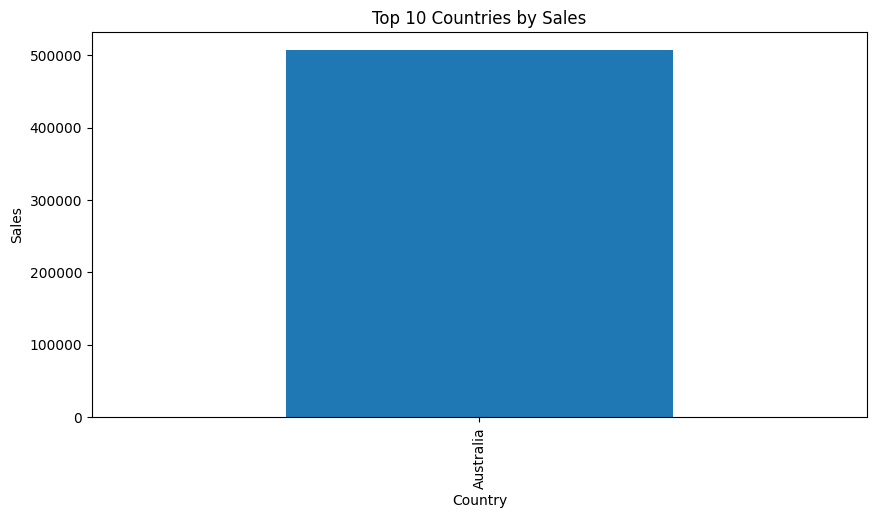

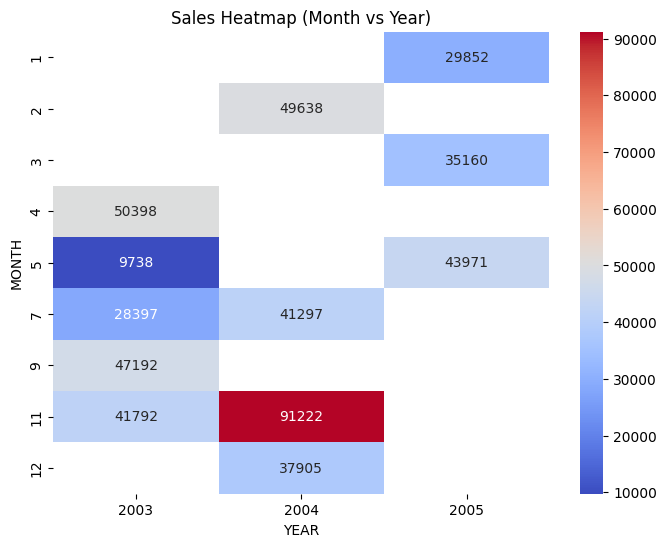

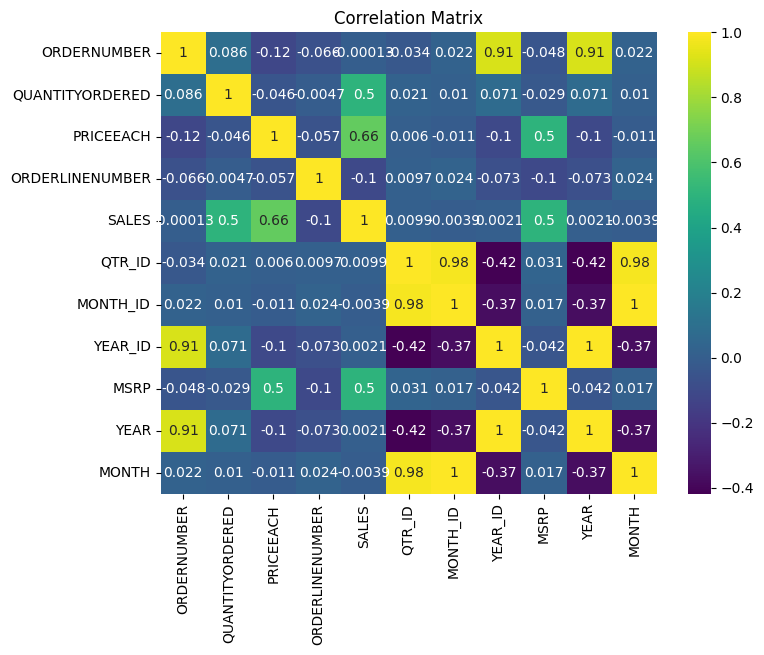

In [ ]:
## DL LAB ASSIGNMENT 6-Perform sentiment analysis with a recurrent neural networks RNN.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("sales_data_sample.csv", encoding='latin1')

# Display dataset
print(df.head())

# Dataset info
print(df.info())

# Check null values
print(df.isnull().sum())

# Drop null values
df = df.dropna()

# Convert ORDERDATE
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

# Extract Year and Month
df['YEAR'] = df['ORDERDATE'].dt.year
df['MONTH'] = df['ORDERDATE'].dt.month

# Sales by Country
country_sales = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)

# Plot Country Sales
plt.figure(figsize=(10,5))
country_sales.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.show()

# Heatmap of Year vs Month
pivot_table = df.pivot_table(values='SALES', index='MONTH', columns='YEAR', aggfunc='sum')

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Sales Heatmap (Month vs Year)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="viridis")
plt.title("Correlation Matrix")
plt.show()